Sample mean = 5.760 min
Sample SD = 0.584
Degrees of freedom = 14
t statistic  = 5.0395
t critical   = ±2.1448
p-value      = 0.000181

Decision: Reject H0 -> Average waiting time is significantly different from 5 minutes.


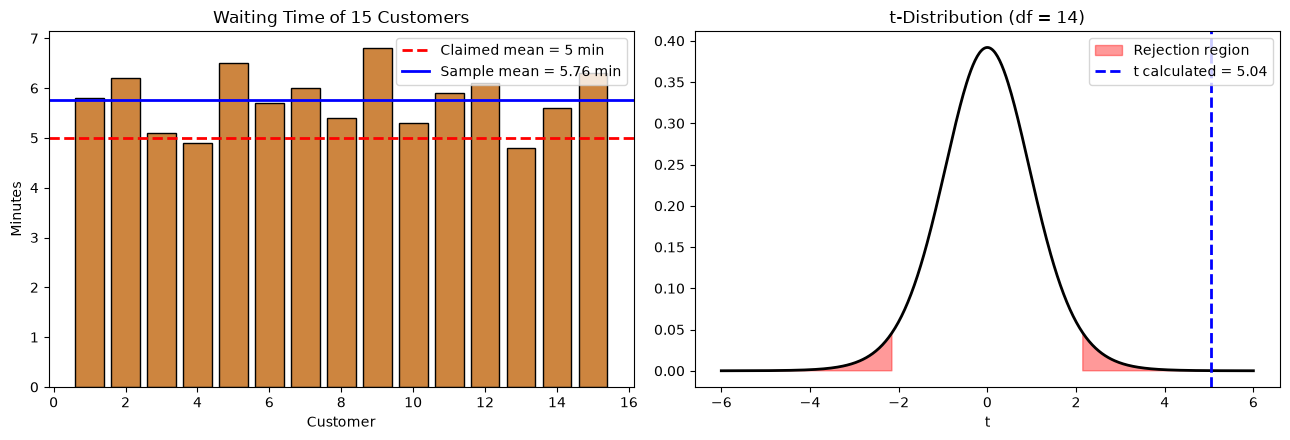

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Data - waiting times (minutes) of 15 customers
wait = np.array([
    5.8, 6.2, 5.1, 4.9, 6.5,
    5.7, 6.0, 5.4, 6.8, 5.3,
    5.9, 6.1, 4.8, 5.6, 6.3
])

mu0 = 5
alpha = 0.05
n = len(wait)
df = n - 1

# Step 2: t-test using scipy
t_stat, p_value = stats.ttest_1samp(wait, popmean=mu0)

t_critical = stats.t.ppf(
    1 - alpha / 2,
    df
)

print(f"Sample mean = {wait.mean():.3f} min")
print(f"Sample SD = {wait.std(ddof=1):.3f}")
print(f"Degrees of freedom = {df}")
print(f"t statistic  = {t_stat:.4f}")
print(f"t critical   = ±{t_critical:.4f}")
print(f"p-value      = {p_value:.6f}")

# Step 3: Decision
if p_value < alpha:
    print("\nDecision: Reject H0 -> Average waiting time is significantly different from 5 minutes.")
else:
    print("\nDecision: Fail to reject H0 -> No significant difference from 5 minutes.")

# Step 4: Graphs
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

# Graph 1: Waiting times
ax[0].bar(
    range(1, n + 1),
    wait,
    color='peru',
    edgecolor='black'
)

ax[0].axhline(
    mu0,
    color='red',
    linestyle='--',
    lw=2,
    label='Claimed mean = 5 min'
)

ax[0].axhline(
    wait.mean(),
    color='blue',
    linestyle='-',
    lw=2,
    label=f'Sample mean = {wait.mean():.2f} min'
)

ax[0].set_title('Waiting Time of 15 Customers')
ax[0].set_xlabel('Customer')
ax[0].set_ylabel('Minutes')
ax[0].legend()

# Graph 2: t-distribution
x = np.linspace(-6, 6, 500)
y = stats.t.pdf(x, df)

ax[1].plot(
    x,
    y,
    'k',
    lw=2
)

ax[1].fill_between(
    x,
    y,
    where=(abs(x) >= t_critical),
    color='red',
    alpha=0.4,
    label='Rejection region'
)

ax[1].axvline(
    t_stat,
    color='blue',
    linestyle='--',
    lw=2,
    label=f't calculated = {t_stat:.2f}'
)

ax[1].set_title(f't-Distribution (df = {df})')
ax[1].set_xlabel('t')
ax[1].legend(loc='upper right')

plt.tight_layout()
plt.show()